<ipython-input-13-66aac396399e>:30: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  features = pd.read_csv('secom.data', delim_whitespace=True, header=None)
<ipython-input-13-66aac396399e>:31: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  labels = pd.read_csv('secom_labels.data', delim_whitespace=True, header=None)


Features shape: (1567, 590)
Labels value counts:
 0
-1    1463
 1     104
Name: count, dtype: int64


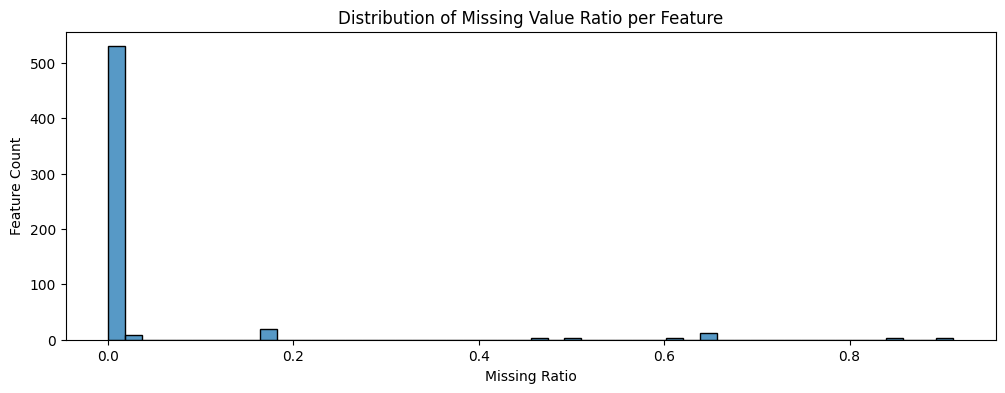

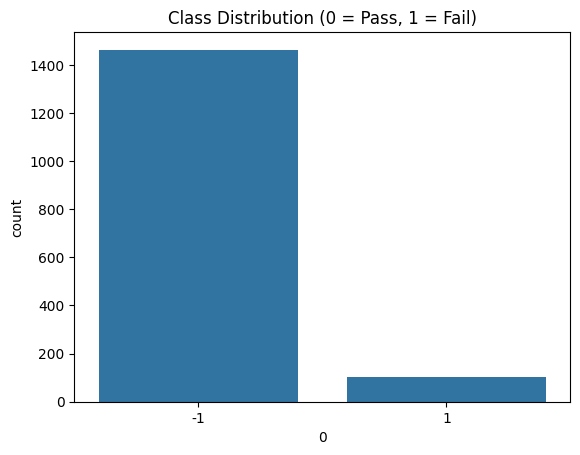

Before SMOTE, counts of label '1': 73
After SMOTE, counts of label '1': 1023
Random Forest Metrics:
Accuracy: 0.9320594479830149
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
ROC AUC: 0.801282991202346

Classification Report:
               precision    recall  f1-score   support

          -1       0.93      1.00      0.96       440
           1       0.00      0.00      0.00        31

    accuracy                           0.93       471
   macro avg       0.47      0.50      0.48       471
weighted avg       0.87      0.93      0.90       471



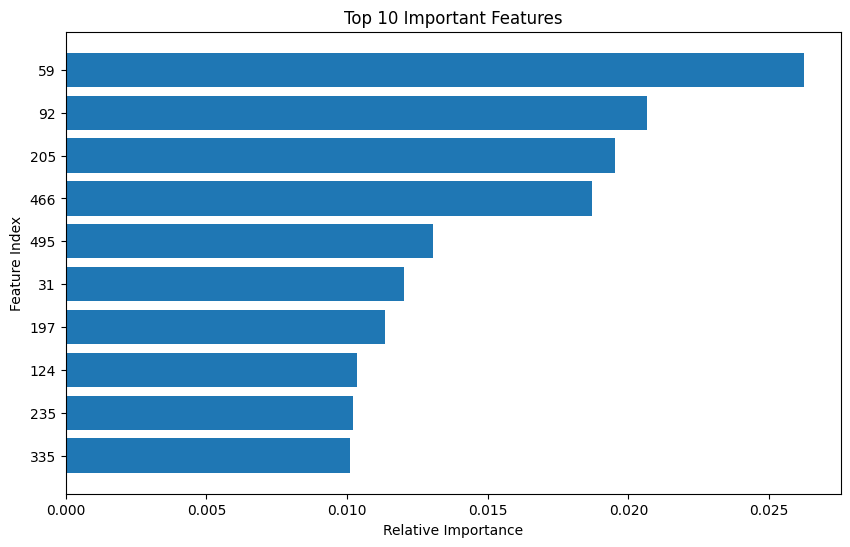


=== Logistic Regression ===
Accuracy: 0.8535031847133758
              precision    recall  f1-score   support

          -1       0.95      0.89      0.92       440
           1       0.17      0.32      0.22        31

    accuracy                           0.85       471
   macro avg       0.56      0.61      0.57       471
weighted avg       0.90      0.85      0.87       471



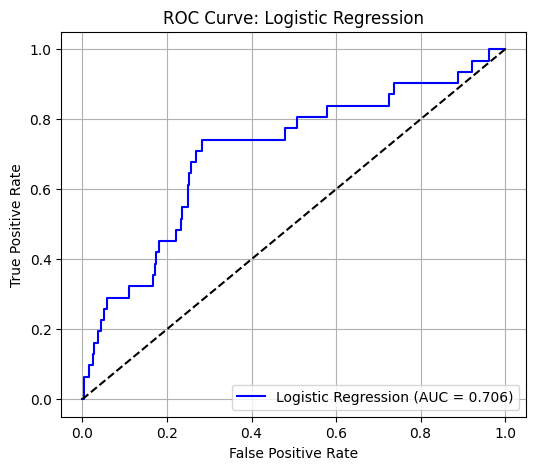

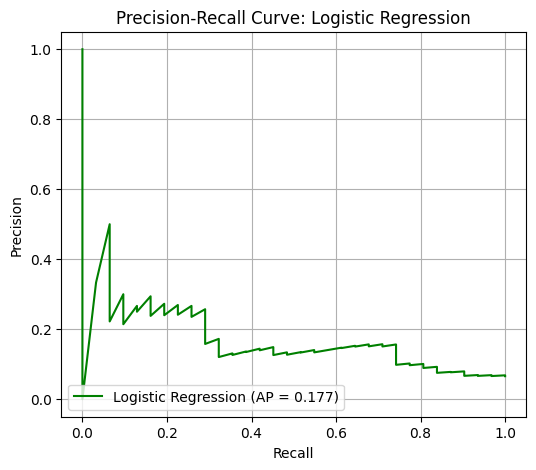

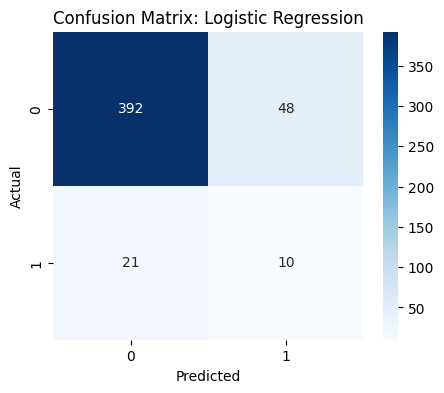


=== Decision Tree ===
Accuracy: 0.8450106157112527
              precision    recall  f1-score   support

          -1       0.94      0.89      0.92       440
           1       0.10      0.16      0.12        31

    accuracy                           0.85       471
   macro avg       0.52      0.53      0.52       471
weighted avg       0.88      0.85      0.86       471



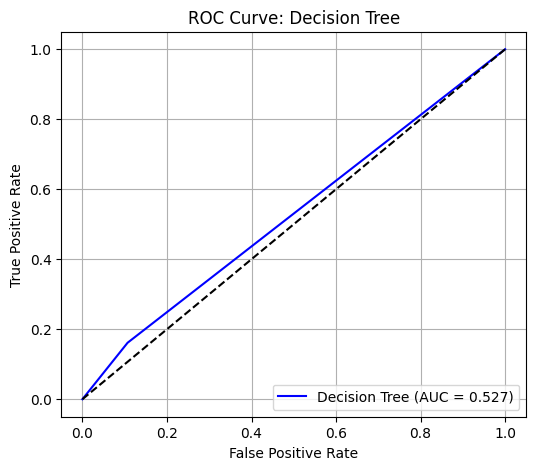

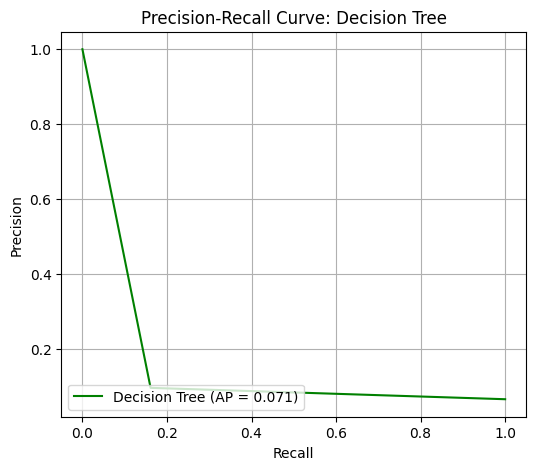

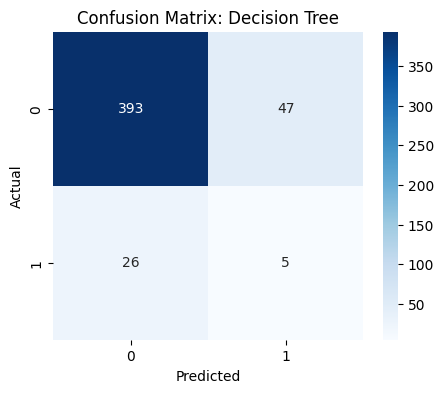


=== Random Forest ===
Accuracy: 0.9320594479830149
              precision    recall  f1-score   support

          -1       0.93      1.00      0.96       440
           1       0.00      0.00      0.00        31

    accuracy                           0.93       471
   macro avg       0.47      0.50      0.48       471
weighted avg       0.87      0.93      0.90       471



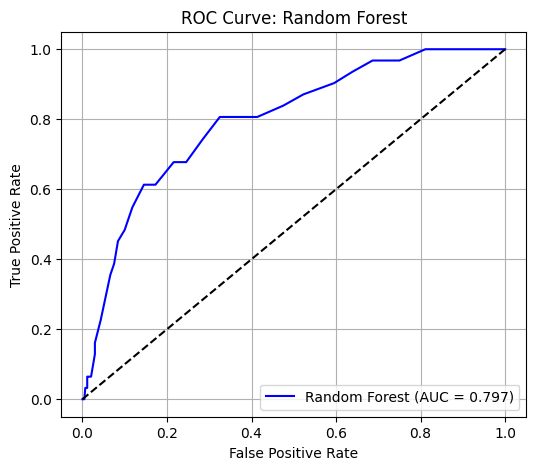

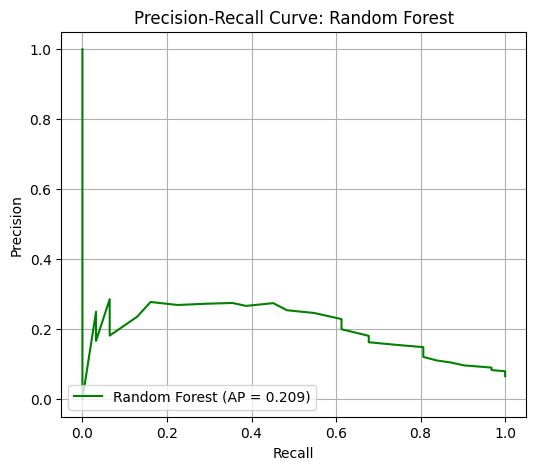

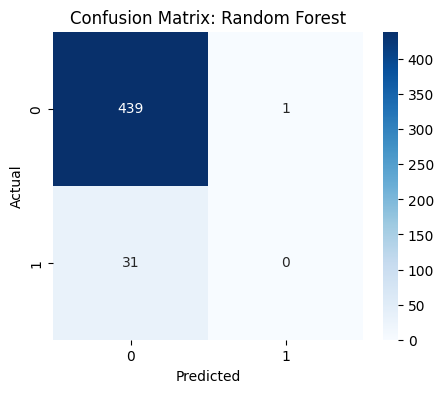


=== SVM ===
Accuracy: 0.9341825902335457
              precision    recall  f1-score   support

          -1       0.94      1.00      0.97       440
           1       0.50      0.06      0.11        31

    accuracy                           0.93       471
   macro avg       0.72      0.53      0.54       471
weighted avg       0.91      0.93      0.91       471



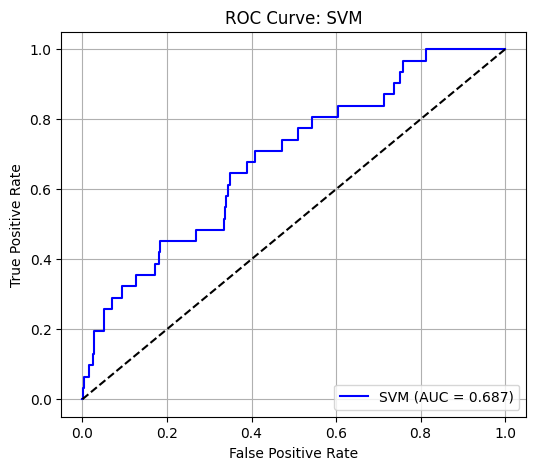

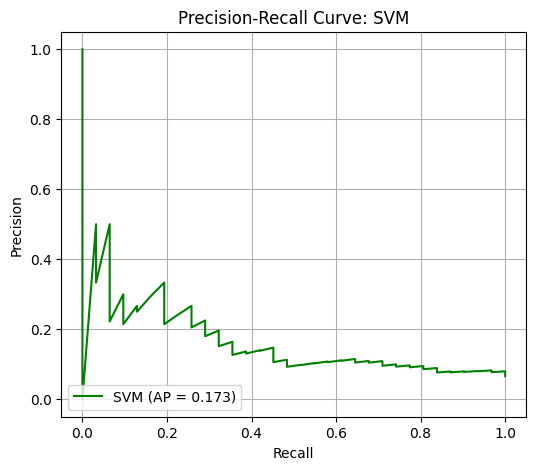

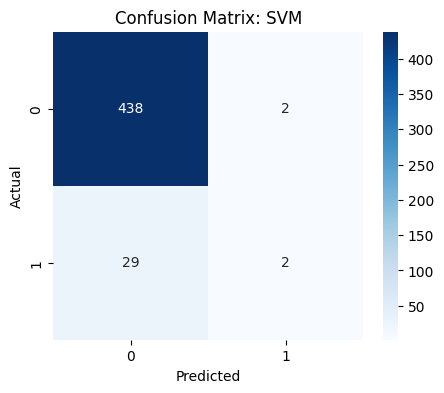


=== KNN ===
Accuracy: 0.2929936305732484
              precision    recall  f1-score   support

          -1       0.93      0.26      0.41       440
           1       0.07      0.74      0.12        31

    accuracy                           0.29       471
   macro avg       0.50      0.50      0.26       471
weighted avg       0.88      0.29      0.39       471



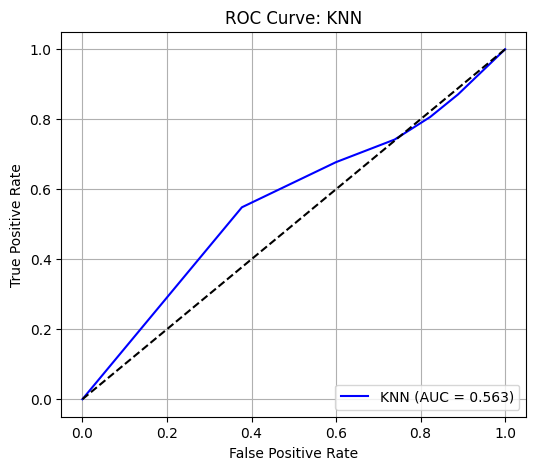

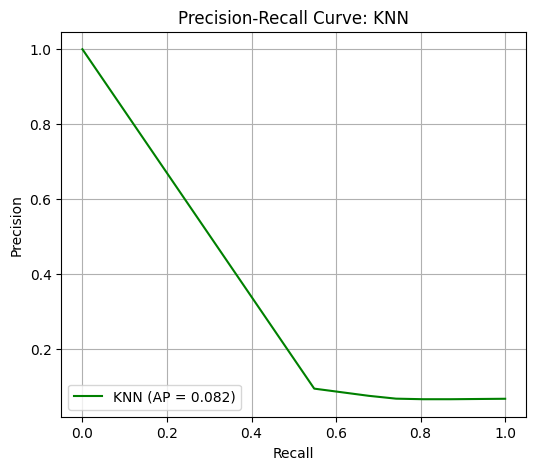

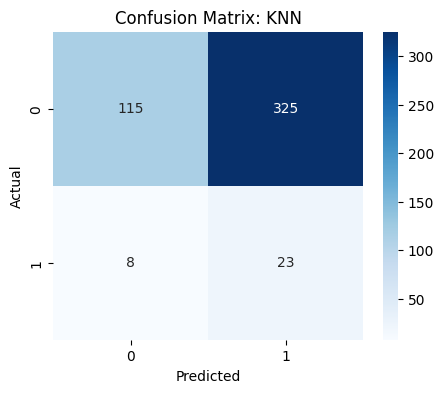

In [13]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score, roc_auc_score,
                             roc_curve, precision_recall_curve, average_precision_score)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


# Optional: to handle class imbalance
from imblearn.over_sampling import SMOTE  # pip install imblearn

# Optional: for dimensionality reduction
from sklearn.decomposition import PCA

# 2. Load the Dataset
features = pd.read_csv('secom.data', delim_whitespace=True, header=None)
labels = pd.read_csv('secom_labels.data', delim_whitespace=True, header=None)

# 3. EDA - Basic Insights
print("Features shape:", features.shape)
print("Labels value counts:\n", labels[0].value_counts())

# 4. EDA - Missing Values
missing_ratio = features.isna().mean()
plt.figure(figsize=(12, 4))
sns.histplot(missing_ratio, bins=50, kde=False)
plt.title("Distribution of Missing Value Ratio per Feature")
plt.xlabel("Missing Ratio")
plt.ylabel("Feature Count")
plt.show()

# Drop columns with >50% missing values (optional)
threshold = 0.5
features = features.loc[:, missing_ratio < threshold]

# 5. EDA - Target Distribution
sns.countplot(x=labels[0])
plt.title("Class Distribution (0 = Pass, 1 = Fail)")
plt.show()

# 6. Impute Missing Values & Scale Features
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(features)
y = labels[0].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Optional: PCA dimensionality reduction (uncomment if you want to use it)
# pca = PCA(n_components=0.95)  # keep 95% variance
# X_scaled = pca.fit_transform(X_scaled)
# print(f"Reduced features to {X_scaled.shape[1]} dimensions using PCA")

# 7. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y)

# 8. Handle Class Imbalance with SMOTE (optional but recommended for SECOM)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print(f"Before SMOTE, counts of label '1': {sum(y_train==1)}")
print(f"After SMOTE, counts of label '1': {sum(y_train_resampled==1)}")

# 9. Train Random Forest Classifier on resampled data
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_resampled, y_train_resampled)

# 10. Predict and Evaluate on test set
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]  # probability for ROC-AUC

print("Random Forest Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 11. Feature importance visualization (Top 10 features)
importances = clf.feature_importances_
indices = np.argsort(importances)[-10:]  # Top 10 features

plt.figure(figsize=(10, 6))
plt.title("Top 10 Important Features")
plt.barh(range(len(indices)), importances[indices], align='center')
plt.xlabel("Relative Importance")
plt.ylabel("Feature Index")
plt.yticks(range(len(indices)), indices)
plt.show()

# 12. Define other models for comparison (Gradient Boosting removed)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
}

# 13. Training and Evaluation of all models with separate plots
results = {}

for name, model in models.items():
    # Train on resampled data
    model.fit(X_train_resampled, y_train_resampled)
    y_pred = model.predict(X_test)

    # Some models (like SVM, RandomForest) have predict_proba; KNN also supports it
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"\n=== {name} ===")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))

    # Plot ROC Curve separately if predict_proba available
    if y_proba is not None:
        roc_auc = roc_auc_score(y_test, y_proba)
        fpr, tpr, _ = roc_curve(y_test, y_proba)

        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})", color='blue')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.title(f"ROC Curve: {name}")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.show()

        # Precision-Recall Curve
        precision, recall, _ = precision_recall_curve(y_test, y_proba)
        avg_precision = average_precision_score(y_test, y_proba)

        plt.figure(figsize=(6, 5))
        plt.plot(recall, precision, label=f"{name} (AP = {avg_precision:.3f})", color='green')
        plt.title(f"Precision-Recall Curve: {name}")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.legend(loc="lower left")
        plt.grid(True)
        plt.show()

    # Confusion Matrix per model
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix: {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
